<a href="https://colab.research.google.com/github/Akash14-09/CP_Coach/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Phase 1 --> Data Collection

In [51]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [52]:
handle = "akashdwivedi1409"

url = f"https://codeforces.com/api/user.info?handles={handle}"

response = requests.get(url)

data = response.json()

data

{'status': 'OK',
 'result': [{'lastName': 'Dwivedi',
   'country': 'India',
   'lastOnlineTimeSeconds': 1780193458,
   'city': 'Pratāpgarh',
   'rating': 570,
   'friendOfCount': 31,
   'titlePhoto': 'https://userpic.codeforces.org/4917734/title/d299031c37d157f7.jpg',
   'handle': 'akashdwivedi1409',
   'avatar': 'https://userpic.codeforces.org/4917734/avatar/71bed56776fe2b9e.jpg',
   'firstName': 'Akash',
   'contribution': 0,
   'organization': 'BIET, Jhansi',
   'rank': 'newbie',
   'maxRating': 941,
   'registrationTimeSeconds': 1750341472,
   'maxRank': 'newbie'}]}

In [53]:
user = data['result'][0]

user_info = {
    "handle": user.get("handle"),
    "rating": user.get("rating"),
    "maxRating": user.get("maxRating"),
    "rank": user.get("rank"),
    "maxRank": user.get("maxRank"),
    "contribution": user.get("contribution"),
    "friendOfCount": user.get("friendOfCount")
}

user_info

{'handle': 'akashdwivedi1409',
 'rating': 570,
 'maxRating': 941,
 'rank': 'newbie',
 'maxRank': 'newbie',
 'contribution': 0,
 'friendOfCount': 31}

In [54]:
url = f"https://codeforces.com/api/user.status?handle={handle}"

response = requests.get(url)

data = response.json()

submissions = data['result']

len(submissions)

846

In [55]:
rows = []

for sub in submissions:

    rows.append({
        "submission_id": sub.get("id"),
        "problem_name": sub["problem"].get("name"),
        "rating": sub["problem"].get("rating"),
        "tags": sub["problem"].get("tags"),
        "verdict": sub.get("verdict"),
        "language": sub.get("programmingLanguage"),
        "creation_time": sub.get("creationTimeSeconds")
    })

df = pd.DataFrame(rows)

df.head()

,submission_id,problem_name,rating,tags,verdict,language,creation_time
0,376747184,Fox And Names,1600.0,"[dfs and similar, graphs, sortings]",OK,"C++23 (GCC 14-64, msys2)",1780209103
1,376746923,Fox And Names,1600.0,"[dfs and similar, graphs, sortings]",WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",1780208922
2,376745935,Fox And Names,1600.0,"[dfs and similar, graphs, sortings]",WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",1780208204
3,376735900,White-Black Balanced Subtrees,1300.0,"[dfs and similar, dp, graphs, trees]",OK,"C++23 (GCC 14-64, msys2)",1780200242
4,376626451,Xenia and Bit Operations,1700.0,"[data structures, trees]",OK,"C++23 (GCC 14-64, msys2)",1780149839


In [56]:
df['rating'].mean()
#avg of all the problems that i solved till now

np.float64(1084.9878934624696)

In [57]:
df["verdict"].value_counts()

,count
verdict,
OK,468
WRONG_ANSWER,297
TIME_LIMIT_EXCEEDED,38
COMPILATION_ERROR,33
RUNTIME_ERROR,5
MEMORY_LIMIT_EXCEEDED,3
SKIPPED,1
IDLENESS_LIMIT_EXCEEDED,1


In [58]:
df["language"].value_counts().head(10)

,count
language,
C++20 (GCC 13-64),540
"C++23 (GCC 14-64, msys2)",296
GNU C11,8
C++17 (GCC 7-32),1
PyPy 3-64,1


In [59]:
all_tags = []

for tags in df["tags"]:

    if isinstance(tags, list):
        all_tags.extend(tags)

tag_counts = Counter(all_tags)

tag_counts.most_common(10)

[('math', 370),
 ('greedy', 357),
 ('implementation', 261),
 ('brute force', 174),
 ('dp', 162),
 ('sortings', 122),
 ('constructive algorithms', 116),
 ('number theory', 88),
 ('binary search', 77),
 ('data structures', 69)]

In [60]:
#converting the scientific time to readable creation time

In [61]:
df["creation_time"] = pd.to_datetime(
    df["creation_time"],
    unit="s"
)

df.head()

,submission_id,problem_name,rating,tags,verdict,language,creation_time
0,376747184,Fox And Names,1600.0,"[dfs and similar, graphs, sortings]",OK,"C++23 (GCC 14-64, msys2)",2026-05-31 06:31:43
1,376746923,Fox And Names,1600.0,"[dfs and similar, graphs, sortings]",WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",2026-05-31 06:28:42
2,376745935,Fox And Names,1600.0,"[dfs and similar, graphs, sortings]",WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",2026-05-31 06:16:44
3,376735900,White-Black Balanced Subtrees,1300.0,"[dfs and similar, dp, graphs, trees]",OK,"C++23 (GCC 14-64, msys2)",2026-05-31 04:04:02
4,376626451,Xenia and Bit Operations,1700.0,"[data structures, trees]",OK,"C++23 (GCC 14-64, msys2)",2026-05-30 14:03:59


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   submission_id  846 non-null    int64         
 1   problem_name   846 non-null    object        
 2   rating         826 non-null    float64       
 3   tags           846 non-null    object        
 4   verdict        846 non-null    object        
 5   language       846 non-null    object        
 6   creation_time  846 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 46.4+ KB


In [63]:
df["year"] = df["creation_time"].dt.year
df["month"] = df["creation_time"].dt.month
df["day"] = df["creation_time"].dt.day

In [64]:
df.to_csv("akashdwivedi1409_submissions_updated.csv", index=False)

In [65]:
# from google.colab import files

# files.download("akashdwivedi1409_submissions_updated.csv")

##Phase 2 --> Feature Engineering

###Solve Rate
How many solutions are getting accepted

In [66]:
total_submissions = len(df)

accepted = len(df[df["verdict"] == "OK"])

solve_rate = (accepted / total_submissions) * 100

print("Solve Rate:", round(solve_rate, 2), "%")

Solve Rate: 55.32 %


In [67]:
#avg solved rating
solved_df = df[df["verdict"] == "OK"]
solved_df["rating"].mean()

np.float64(1089.3939393939395)

In [68]:
#Hardest solved problem

In [69]:
solved_df["rating"].max()

2000.0

##Strength Detection :


1.   Accepted Submissions
2.   Problem Difficulty Ratings
3.   Success Rate
4.   Average Solved Difficulty








In [70]:
# Remove rows where rating is missing
strong_df = df[
    (df["verdict"] == "OK") &
    (df["rating"].notnull())
].copy()


topic_strength = {}

for _, row in strong_df.iterrows():

    tags = row["tags"]
    rating = row["rating"]

    if not isinstance(tags, list):
        continue

    for tag in tags:

        if tag not in topic_strength:

            topic_strength[tag] = {

                "solved_count": 0,

                "total_rating": 0,
                "max_rating": 0
            }


        topic_strength[tag]["solved_count"] += 1

        topic_strength[tag]["total_rating"] += rating

        topic_strength[tag]["max_rating"] = max(
            topic_strength[tag]["max_rating"],
            rating
        )


strong_topic_scores = []

for tag, stats in topic_strength.items():

    solved_count = stats["solved_count"]

    avg_rating = (
        stats["total_rating"] / solved_count
    )

    max_rating = stats["max_rating"]



    import math

    mastery_score = (
        math.log1p(solved_count) *
        avg_rating *
        0.7
        +
        max_rating *
        0.3
    )


    strong_topic_scores.append({

        "topic": tag,

        "solved_count": solved_count,

        "average_solved_rating": round(avg_rating, 2),

        "hardest_solved": max_rating,

        "mastery_score": round(mastery_score, 2)
    })


#sort by strong topics --> on the basis of mastery score
strong_topic_scores = sorted(
    strong_topic_scores,
    key=lambda x: x["mastery_score"],
    reverse=True
)

#printing top 10 strong topics
top_n = 10

for topic in strong_topic_scores[:top_n]:

    print(topic)
    print(" ")


{'topic': 'greedy', 'solved_count': 189, 'average_solved_rating': 1071.96, 'hardest_solved': 1700.0, 'mastery_score': 4447.21}
 
{'topic': 'math', 'solved_count': 193, 'average_solved_rating': 1065.8, 'hardest_solved': 1700.0, 'mastery_score': 4440.15}
 
{'topic': 'dp', 'solved_count': 103, 'average_solved_rating': 1189.32, 'hardest_solved': 1700.0, 'mastery_score': 4376.57}
 
{'topic': 'implementation', 'solved_count': 136, 'average_solved_rating': 1059.56, 'hardest_solved': 2000.0, 'mastery_score': 4249.11}
 
{'topic': 'brute force', 'solved_count': 99, 'average_solved_rating': 1083.84, 'hardest_solved': 2000.0, 'mastery_score': 4093.88}
 
{'topic': 'binary search', 'solved_count': 49, 'average_solved_rating': 1306.12, 'hardest_solved': 1700.0, 'mastery_score': 4086.71}
 
{'topic': 'data structures', 'solved_count': 42, 'average_solved_rating': 1307.14, 'hardest_solved': 1700.0, 'mastery_score': 3951.5}
 
{'topic': 'sortings', 'solved_count': 68, 'average_solved_rating': 1145.59, 'ha

weakness detection --> gives you all the failed submissions for each topic

In [71]:
weak_df = df[
    (df["verdict"] != "OK") &
    (df["rating"].notnull())
].copy()

topic_weakness = {}


for _, row in weak_df.iterrows():

    tags = row["tags"]
    rating = row["rating"]

    if not isinstance(tags, list):
        continue

    for tag in tags:


        if tag not in topic_weakness:

            topic_weakness[tag] = {


                "failed_count": 0,


                "failed_rating_sum": 0,

                "hardest_failed": 0
            }


        topic_weakness[tag]["failed_count"] += 1

        topic_weakness[tag]["failed_rating_sum"] += rating

        topic_weakness[tag]["hardest_failed"] = max(
            topic_weakness[tag]["hardest_failed"],
            rating
        )



weak_topic_scores = []

for tag, stats in topic_weakness.items():

    failed_count = stats["failed_count"]

    avg_failed_rating = (
        stats["failed_rating_sum"] / failed_count
    )

    hardest_failed = stats["hardest_failed"]



    import math

    weakness_score = (

        math.log1p(failed_count) *
        avg_failed_rating *
        0.7

        +

        hardest_failed *
        0.3
    )


    weak_topic_scores.append({

        "topic": tag,

        "failed_count": failed_count,

        "average_failed_rating": round(avg_failed_rating, 2),

        "hardest_failed": hardest_failed,

        "weakness_score": round(weakness_score, 2)
    })

weak_topic_scores = sorted(
    weak_topic_scores,
    key=lambda x: x["weakness_score"],
    reverse=True
)

top_n = 10

for topic in weak_topic_scores[:top_n]:

    print(topic)
    print(" ")

{'topic': 'implementation', 'failed_count': 119, 'average_failed_rating': 1056.3, 'hardest_failed': 3000.0, 'weakness_score': 4439.93}
 
{'topic': 'math', 'failed_count': 177, 'average_failed_rating': 1062.15, 'hardest_failed': 1700.0, 'weakness_score': 4362.67}
 
{'topic': 'greedy', 'failed_count': 168, 'average_failed_rating': 1060.12, 'hardest_failed': 1700.0, 'weakness_score': 4316.81}
 
{'topic': 'dp', 'failed_count': 59, 'average_failed_rating': 1211.86, 'hardest_failed': 2500.0, 'weakness_score': 4223.25}
 
{'topic': 'brute force', 'failed_count': 74, 'average_failed_rating': 1029.73, 'hardest_failed': 2500.0, 'weakness_score': 3862.09}
 
{'topic': 'sortings', 'failed_count': 54, 'average_failed_rating': 1111.11, 'hardest_failed': 1600.0, 'weakness_score': 3596.81}
 
{'topic': 'number theory', 'failed_count': 43, 'average_failed_rating': 1169.77, 'hardest_failed': 1600.0, 'weakness_score': 3578.64}
 
{'topic': 'constructive algorithms', 'failed_count': 57, 'average_failed_rating

##Phase 2 --> Analytics Engine


*   Rating Distribution Analytics

*   Contest Performance Analytics

*   Problem Difficulty Success Score

*   Consistency Score

*   Weakness Security Index

*   Consistency Curve


*   Personalized Problems Recommendator


*   Readiness Score


*   Rating Growth Predictor


*   Solve Probability Predictor





1) Rating Distritbution Analytics

In [72]:
import pandas as pd
import numpy as np

# Keep only accepted submissions
solved_df = df[df["verdict"] == "OK"].copy()

# Remove unrated problems
solved_df = solved_df[solved_df["rating"].notna()]

# Keep only first occurrence of each solved problem
solved_df = solved_df.drop_duplicates(
    subset=["problem_name"]
)

print("Unique solved problems:", len(solved_df))

Unique solved problems: 388


In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class RatingDistributionAnalyzer:

    def __init__(self, solved_df):
        self.df = solved_df.copy()

    def calculate_metrics(self):

        ratings = self.df["rating"]

        avg_rating = ratings.mean()

        median_rating = ratings.median()

        std_rating = ratings.std()

        max_rating = ratings.max()

        min_rating = ratings.min()

        lower_q = np.percentile(ratings, 25)

        upper_q = np.percentile(ratings, 75)

        comfort_zone = (
            int(lower_q),
            int(upper_q)
        )

        stretch_zone = (
            int(upper_q),
            int(upper_q + 200)
        )

        return {
            "avg_rating": round(avg_rating, 2),
            "median_rating": median_rating,
            "std_rating": round(std_rating, 2),
            "max_rating": max_rating,
            "min_rating": min_rating,
            "comfort_zone": comfort_zone,
            "stretch_zone": stretch_zone
        }

    def rating_distribution(self):

        dist = (
            self.df.groupby("rating")
            .size()
            .reset_index(name="count")
            .sort_values("rating")
        )

        return dist

    def detect_growth_barrier(self):

      dist = self.rating_distribution()

      ratings = dist["rating"].values
      counts = dist["count"].values

      if len(ratings) < 3:
          return None

      peak_idx = np.argmax(counts)

      peak_count = counts[peak_idx]

      # Barrier = first rating after peak
      # where solve count drops below 40% of peak

      threshold = 0.40 * peak_count

      for i in range(peak_idx + 1, len(counts)):

          if counts[i] <= threshold:
              return ratings[i]

      return ratings[-1]


    def generate_insights(self):

        metrics = self.calculate_metrics()

        barrier = self.detect_growth_barrier()

        insights = []

        insights.append(
            f"Average solved rating: {metrics['avg_rating']}"
        )

        insights.append(
            f"Comfort zone: {metrics['comfort_zone'][0]} - {metrics['comfort_zone'][1]}"
        )

        insights.append(
            f"Stretch zone: {metrics['stretch_zone'][0]} - {metrics['stretch_zone'][1]}"
        )

        insights.append(
            f"Highest solved rating: {metrics['max_rating']}"
        )

        if barrier:
            insights.append(
                f"Growth barrier detected around rating {barrier}"
            )

        return insights

    def get_cf_color(self, rating):

        if rating < 1200:
            return "#B0B0B0"      # Newbie

        elif rating < 1400:
            return "#00AA00"      # Pupil (Green)

        elif rating < 1600:
            return "#03A9F4"      # Specialist (Cyan)

        elif rating < 1900:
            return "#0000FF"      # Expert (Blue)

        elif rating < 2100:
            return "#AA00AA"      # Candidate Master

        elif rating < 2400:
            return "#FF8C00"      # Master

        elif rating < 3000:
            return "#FF0000"      # Grandmaster

        else:
            return "#8B0000"      # Legendary GM

    def plot_rating_distribution(self):

        dist = self.rating_distribution()

        ratings = dist["rating"].values
        counts = dist["count"].values

        colors = [self.get_cf_color(r) for r in ratings]

        plt.figure(figsize=(14,7))

        bars = plt.bar(
            ratings,
            counts,
            width=90,
            color=colors,

            # WHITE BORDER
            edgecolor="white",
            linewidth=2
        )

        plt.title(
            "Rating Distribution (Unique Solved Problems)",
            fontsize=18,
            fontweight="bold"
        )

        plt.xlabel(
            "Problem Rating",
            fontsize=12
        )

        plt.ylabel(
            "Solved Count",
            fontsize=12
        )

        plt.xticks(ratings)

        plt.grid(
            axis="y",
            linestyle="--",
            alpha=0.4
        )

        # Count labels above bars
        for bar in bars:

            h = bar.get_height()

            plt.text(
                bar.get_x() + bar.get_width()/2,
                h + 1,
                str(int(h)),
                ha="center",
                fontsize=9,
                fontweight="bold"
            )

        plt.tight_layout()
        plt.show()


In [91]:
import matplotlib.pyplot as plt

def plot_rating_distribution(solved_df):
  plt.figure(figsize  = (12,6))

  plt.hist(solved_df["rating"] , bins = 20)

  plt.xlabel("Problem Rating")

  plt.ylabel("Solved Count")

  plt.title("Rating Distribution")

  plt.grid(True)

  plt.show()

{'avg_rating': np.float64(1089.95), 'median_rating': 1100.0, 'std_rating': 275.39, 'max_rating': 2000.0, 'min_rating': 800.0, 'comfort_zone': (800, 1300), 'stretch_zone': (1300, 1500)}

Growth Barrier: 900.0

• Average solved rating: 1089.95
• Comfort zone: 800 - 1300
• Stretch zone: 1300 - 1500
• Highest solved rating: 2000.0
• Growth barrier detected around rating 900.0


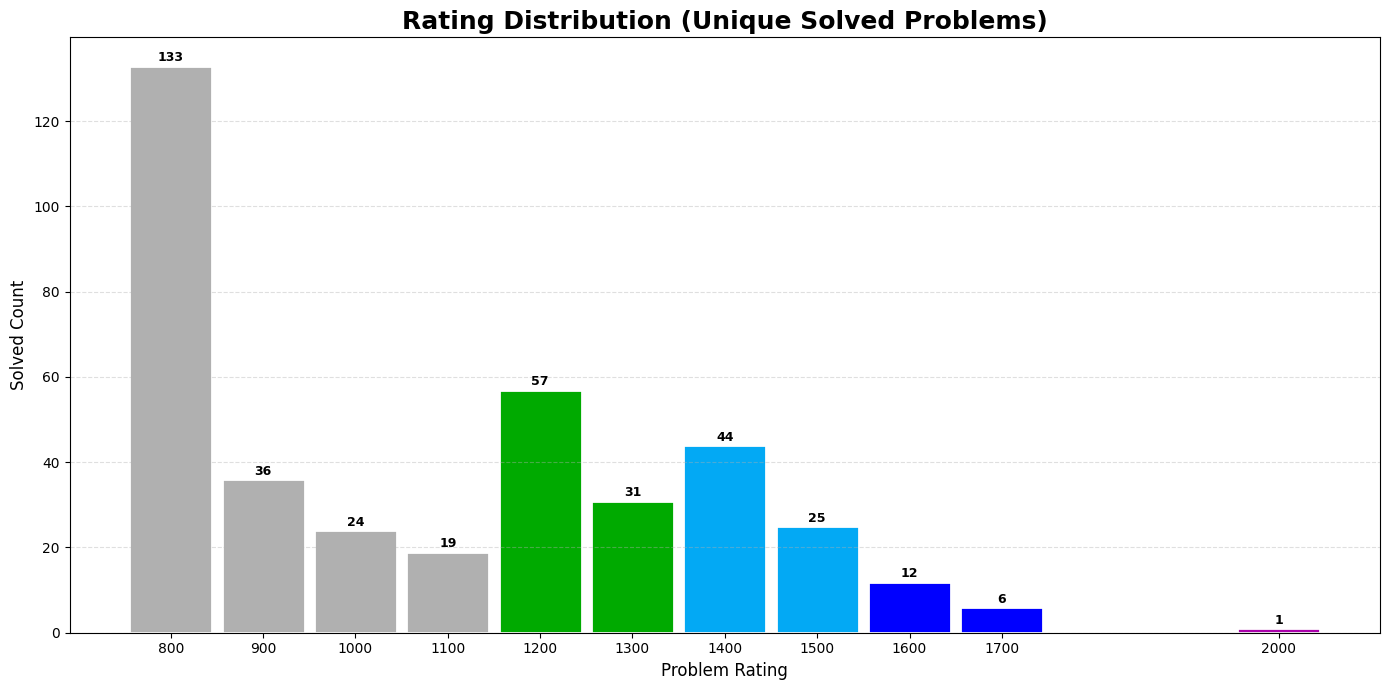

In [94]:
analyzer = RatingDistributionAnalyzer(
    solved_df
)

metrics = analyzer.calculate_metrics()

distribution = analyzer.rating_distribution()

growth_barrier = analyzer.detect_growth_barrier()

insights = analyzer.generate_insights()

print(metrics)

print()

print("Growth Barrier:", growth_barrier)

print()

for line in insights:
    print("•", line)

analyzer.plot_rating_distribution()